In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest,chi2,RFE
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression


def lda_test(X_train,y_train,X_test,n):
    test=LinearDiscriminantAnalysis(n_components=n)
    xtrain_lda=test.fit_transform(X_train,y_train)
    xtest_lda=test.transform(X_test)
    return xtrain_lda,xtest_lda

def split_scaler(indep_X,dep_Y):
    X_train,X_test,y_train,y_test=train_test_split(indep_X,dep_Y,test_size=0.25,random_state=0)
    sc=StandardScaler()
    X_train=sc.fit_transform(X_train)
    X_test=sc.transform(X_test)
    return X_train,X_test,y_train,y_test

def cm_predictions(classifier,xtest_lda,y_test):
    y_pred=classifier.predict(xtest_lda)
    from sklearn.metrics import confusion_matrix
    from sklearn.metrics import accuracy_score
    from sklearn.metrics import classification_report
    cm=confusion_matrix(y_test,y_pred)
    accuracy=accuracy_score(y_test,y_pred)
    report=classification_report(y_test,y_pred)
    return classifier,accuracy,report,xtest_lda,y_test,cm

def logistic(xtrain_lda,xtest_lda,y_train,y_test):
    from sklearn.linear_model import LogisticRegression
    classifier=LogisticRegression(random_state=0)
    classifier.fit(xtrain_lda,y_train)
    classifier,accuracy,report,X_test,y_test,cm=cm_predictions(classifier,xtest_lda,y_test)
    return classifier,accuracy,report,xtest_lda,y_test,cm

def svm_linear(xtrain_lda,xtest_lda,y_train,y_test):
    from sklearn.svm import SVC
    classifier = SVC(kernel = 'linear', random_state = 0)
    classifier.fit(xtrain_lda,y_train)
    classifier,accuracy,report,X_test,y_test,cm=cm_predictions(classifier,xtest_lda,y_test)
    return classifier,accuracy,report,xtest_lda,y_test,cm

def svm_NL(xtrain_lda,xtest_lda,y_train,y_test):
    from sklearn.svm import SVC
    classifier = SVC(kernel = 'rbf', random_state = 0)
    classifier.fit(xtrain_lda,y_train)
    classifier,accuracy,report,X_test,y_test,cm=cm_predictions(classifier,xtest_lda,y_test)
    return classifier,accuracy,report,xtest_lda,y_test,cm

def Navie(xtrain_lda,xtest_lda,y_train,y_test):
    from sklearn.naive_bayes import GaussianNB
    classifier = GaussianNB()
    classifier.fit(xtrain_lda,y_train)
    classifier,accuracy,report,X_test,y_test,cm=cm_predictions(classifier,xtest_lda,y_test)
    return classifier,accuracy,report,xtest_lda,y_test,cm

def knn(xtrain_lda,xtest_lda,y_train,y_test):
    from sklearn.neighbors import KNeighborsClassifier
    classifier = KNeighborsClassifier(n_neighbors = 5, metric = 'minkowski', p = 2)
    classifier.fit(xtrain_lda,y_train)
    classifier,accuracy,report,X_test,y_test,cm=cm_predictions(classifier,xtest_lda,y_test)
    return classifier,accuracy,report,xtest_lda,y_test,cm
    
def decision(xtrain_lda,xtest_lda,y_train,y_test):
    from sklearn.tree import DecisionTreeClassifier
    classifier = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)
    classifier.fit(xtrain_lda,y_train)
    classifier,accuracy,report,X_test,y_test,cm=cm_predictions(classifier,xtest_lda,y_test)
    return classifier,accuracy,report,xtest_lda,y_test,cm

def random(xtrain_lda,xtest_lda,y_train,y_test):
    from sklearn.ensemble import RandomForestClassifier
    classifier = RandomForestClassifier(n_estimators = 10, criterion = 'entropy', random_state = 0)
    classifier.fit(xtrain_lda,y_train)
    classifier,accuracy,report,X_test,y_test,cm=cm_predictions(classifier,xtest_lda,y_test)
    return classifier,accuracy,report,xtest_lda,y_test,cm

def LDA_classification(acclog,accsvml,accsvmnl,accknn,accnav,accdes,accrf):
    dataframe=pd.DataFrame({
        'Logistic': [acclog[0]],
        'SVMl': [accsvml[0]],
        'SVMnl': [accsvmnl[0]],
        'KNN': [accknn[0]],
        'Navie': [accnav[0]],
        'Decision': [accdes[0]],
        'Random': [accrf[0]]},index=['ChiSquare'])
    return dataframe
        

#===========================

dataset=pd.read_csv("prep.csv")
df2=dataset
df2=pd.get_dummies(df2,drop_first=True)

indep_X=df2.drop("classification_yes",axis=1)
dep_Y=df2["classification_yes"]

acclog=[]
accsvml=[]
accsvmnl=[]
accknn=[]
accnav=[]
accdes=[]
accrf=[]

X_train, X_test, y_train, y_test=split_scaler(indep_X,dep_Y)   

xtrain_lda,xtest_lda=lda_test(X_train,y_train,X_test,1)
          
classifier,accuracy,report,X_test,y_test,cm=logistic(xtrain_lda,xtest_lda,y_train,y_test)
acclog.append(accuracy)

classifier,accuracy,report,X_test,y_test,cm=svm_linear(xtrain_lda,xtest_lda,y_train,y_test)  
accsvml.append(accuracy)
    
classifier,accuracy,report,X_test,y_test,cm=svm_NL(xtrain_lda,xtest_lda,y_train,y_test)  
accsvmnl.append(accuracy)
    
classifier,accuracy,report,X_test,y_test,cm=knn(xtrain_lda,xtest_lda,y_train,y_test)  
accknn.append(accuracy)
    
classifier,accuracy,report,X_test,y_test,cm=Navie(xtrain_lda,xtest_lda,y_train,y_test)  
accnav.append(accuracy)
    
classifier,accuracy,report,X_test,y_test,cm=decision(xtrain_lda,xtest_lda,y_train,y_test)  
accdes.append(accuracy)
    
classifier,accuracy,report,X_test,y_test,cm=random(xtrain_lda,xtest_lda,y_train,y_test)  
accrf.append(accuracy)
    
result=LDA_classification(acclog,accsvml,accsvmnl,accknn,accnav,accdes,accrf)



In [13]:
result

,Logistic,SVMl,SVMnl,KNN,Navie,Decision,Random
ChiSquare,0.96,0.96,0.96,0.96,0.96,0.95,0.95


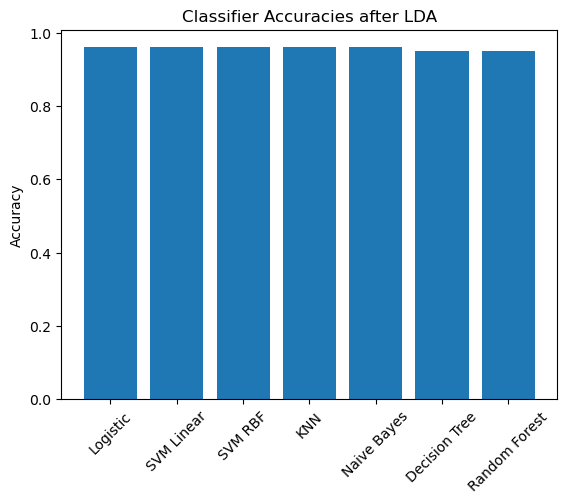

In [14]:
import matplotlib.pyplot as plt

models = ['Logistic','SVM Linear','SVM RBF','KNN','Naive Bayes','Decision Tree','Random Forest']
accuracies = [0.96,0.96,0.96,0.96,0.96,0.95,0.95]

plt.bar(models, accuracies)
plt.title("Classifier Accuracies after LDA")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.show()